In [1]:
import pandas as pd

In [5]:
base_hu = pd.read_csv('../data/synthetic_housing_units_2026-09-25.csv').groupby('maz_id').size()

In [7]:
blks = pd.read_csv('../data/blocks_2020_2026-09-28.csv')

In [6]:
base_hu

maz_id
1         20
2         30
3        246
4         20
5         18
        ... 
54411      1
54414      1
54415      4
54416      1
54421     28
Length: 41586, dtype: int64

In [11]:
obs_hu = pd.read_csv('../data/observed_data_2026-09-28.csv')
obs_hu.loc[obs_hu['type'] == 'housing_units'].set_index('maz_id')['value']

maz_id
1         21
2         30
3        268
4         20
5         20
        ... 
54411      1
54414      1
54415      4
54416      1
54421     29
Name: value, Length: 41740, dtype: int64

In [9]:
blks['hu_2020'] = blks['maz_id'].map(base_hu)

In [12]:
blks['hu_2025'] = blks['maz_id'].map(obs_hu.loc[obs_hu['type'] == 'housing_units'].set_index('maz_id')['value'])

In [13]:
blks['tract_id'] = blks['block_id'].astype(str).str[:12].astype('int64')

In [15]:
tracts = blks.groupby('tract_id')[['hu_2020', 'hu_2025']].sum()

In [16]:
tracts['diff'] = tracts['hu_2025'] - tracts['hu_2020']

In [17]:
tracts.sort_values('diff', ascending=False)

,hu_2020,hu_2025,diff
tract_id,,,
153033009100,1975.0,4659.0,2684.0
153033032331,3726.0,5964.0,2238.0
153033009400,3053.0,5259.0,2206.0
153033007302,3535.0,5720.0,2185.0
153053070208,2368.0,4179.0,1811.0
...,...,...,...
153053071207,3402.0,3375.0,-27.0
153033007301,2772.0,2741.0,-31.0
153061041906,1704.0,1672.0,-32.0


In [19]:
hu_calib = pd.read_csv('../data/housing_unit_calib_targets_2026-09-25.csv')

In [30]:
tract_calib = hu_calib.groupby('tract_id')[['units_2010', 'units_2020']].sum().reset_index()

In [31]:
tract_calib['calib_diff'] = tract_calib['units_2020'] - tract_calib['units_2010']
tract_calib.sort_values('calib_diff', ascending=False)

,tract_id,units_2010,units_2020,calib_diff
588,153053070208,490.0,2335.0,1845.0
832,153061052107,1447.0,2622.0,1175.0
674,153053072509,1227.0,2265.0,1038.0
828,153061052009,420.0,1273.0,853.0
477,153033032604,960.0,1793.0,833.0
...,...,...,...,...
720,153053940004,464.0,467.0,3.0
850,153061052401,4.0,6.0,2.0
608,153053071209,149.0,151.0,2.0
676,153053072602,6.0,7.0,1.0


In [32]:
tract_calib.loc[tract_calib['tract_id'] == 153033009100]

,tract_id,units_2010,units_2020,calib_diff
126,153033009100,77.0,132.0,55.0


In [33]:
comp = tracts.merge(tract_calib, on='tract_id', how='left')

In [34]:
comp

,tract_id,hu_2020,hu_2025,diff,units_2010,units_2020,calib_diff
0,153033000101,2040.0,2199.0,159.0,26.0,48.0,22.0
1,153033000102,2189.0,2600.0,411.0,862.0,1018.0,156.0
2,153033000201,2134.0,2205.0,71.0,106.0,154.0,48.0
3,153033000202,1718.0,1778.0,60.0,1072.0,1418.0,346.0
4,153033000300,1196.0,1279.0,83.0,220.0,383.0,163.0
...,...,...,...,...,...,...,...
918,153061053803,2383.0,2844.0,461.0,1699.0,1938.0,239.0
919,153061940001,2445.0,2475.0,30.0,403.0,418.0,15.0
920,153061940002,1856.0,1876.0,20.0,281.0,316.0,35.0
921,153061990002,0.0,0.0,0.0,NaN,NaN,NaN


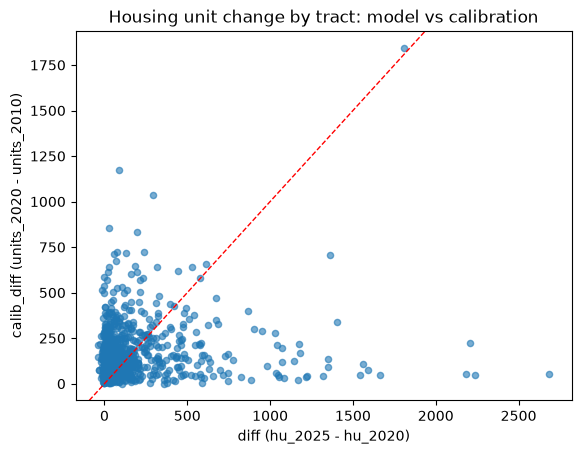

In [35]:
import matplotlib.pyplot as plt

ax = comp.plot.scatter(x='diff', y='calib_diff', alpha=0.6)
ax.set_xlabel('diff (hu_2025 - hu_2020)')
ax.set_ylabel('calib_diff (units_2020 - units_2010)')
ax.set_title('Housing unit change by tract: model vs calibration')
ax.axline((0, 0), slope=1, color='red', linestyle='--', linewidth=1)
plt.show()